In [60]:
import pandas as pd

# load dataset
df = pd.read_csv("auto-mpg.data.txt", sep='\s+', header=None)

# add column names
df.columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [61]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car_name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 30.6+ KB


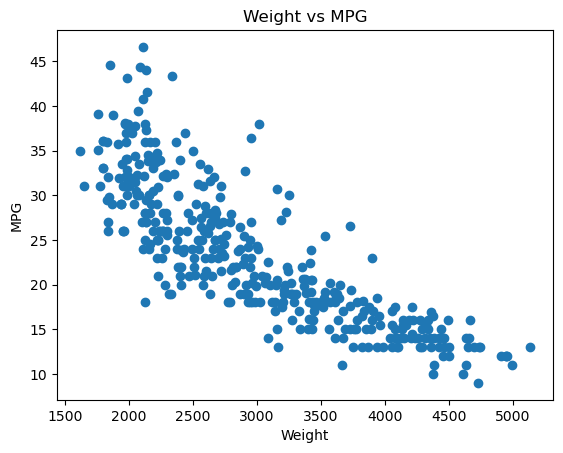

In [62]:
import matplotlib.pyplot as plt

plt.scatter(df["weight"], df["mpg"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

## Model Selection

For this project, I used a Linear Regression model to analyze the relationship between vehicle weight and fuel efficiency (MPG).

Linear regression was chosen because the scatter plot shows a clear linear and negative relationship between weight and MPG. As vehicle weight increases, MPG decreases in a relatively consistent pattern.

I also tested adding multiple features such as horsepower and displacement, but these did not significantly improve the model performance. Therefore, using weight alone provides a simpler and more interpretable model while still explaining most of the variation in MPG.

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# features (X) and target (y)
X = df[["weight"]]
y = df["mpg"]

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

MSE: 17.693388269545686
MAE: 3.4641211922147592
R2: 0.6533466675646016


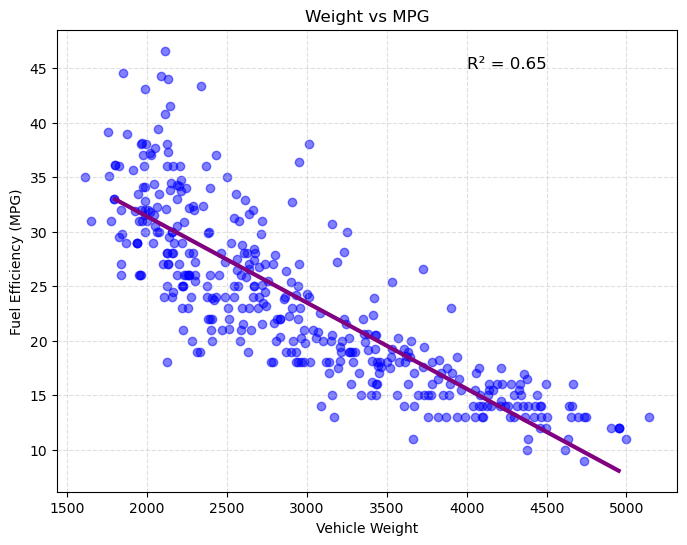

In [65]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(df["weight"], df["mpg"], color="blue", alpha=0.5)

sorted_idx = np.argsort(X_test.values.flatten())
X_sorted = X_test.values.flatten()[sorted_idx]
y_sorted = y_pred[sorted_idx]

plt.plot(X_sorted, y_sorted, color="purple", linewidth=3)

plt.text(4000, 45, f"R² = {r2:.2f}", fontsize=12)

plt.xlabel("Vehicle Weight")
plt.ylabel("Fuel Efficiency (MPG)")
plt.title("Weight vs MPG")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

The regression plot shows a clear negative relationship between vehicle weight and MPG. As vehicle weight increases, fuel efficiency decreases. The R² value is about 0.65, meaning that about 65% of the variation in MPG is explained by vehicle weight.

In [66]:
# tryied to use multiple features
X = df[["weight", "horsepower", "displacement"]]
y = df["mpg"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 18.013911540542004
R2: 0.6470668946730964


Using multiple features (weight, horsepower, and displacement) does not significantly improve the model performance compared to using only vehicle weight. The R² value remains very similar, indicating that weight alone already explains most of the variation in MPG.

The Mean Absolute Error (MAE) is approximately 3.46, meaning that the model’s predictions are off by about 3.5 MPG on average. This provides a more interpretable measure of error compared to MSE.

These results suggest that while horsepower and displacement may have some influence, vehicle weight is the dominant factor affecting fuel efficiency in this dataset.

## Project Significance

This project shows how vehicle characteristics affect fuel efficiency, which is important for both economic and environmental decisions. Understanding that vehicle weight has a strong negative impact on MPG can help manufacturers design more efficient cars and help consumers make better choices.

This project also shows that even a simple model like linear regression can give useful insights from real data.